In [1]:
# Ignore  the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

In [2]:
# data visualisation and manipulation 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
from collections import Counter
 
#configure
# sets matplotlib to inline and displays graphs below the corressponding cell.
%matplotlib inline  
style.use('fivethirtyeight')
sns.set(style='whitegrid',color_codes=True)

#model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,roc_curve,roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

#preprocess.
from keras.preprocessing.image import ImageDataGenerator

#dl libraraies
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical

# specifically for cnn 
from keras.layers import Dropout, Flatten,Activation
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
 
import tensorflow as tf
import random as rn

# specifically for manipulating zipped images and getting numpy arrays of pixel values of images. 
from tqdm import tqdm
import os   
import tempfile
from random import shuffle  
from PIL import Image

In [3]:
plt.rcParams['figure.figsize'] = (8, 6)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

### Tensorflow input piplines

In [4]:
batch_size = 32
img_height = 224
img_width = 224
def load_data(path):
    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        labels='inferred', #generate from directory structure
        label_mode = 'binary', #describing the encoding of labels
        class_names = ['nevus_keratosis', 'melanoma'],#Explicitly specify class order 0,1
        image_size = (img_height, img_width),
        batch_size = batch_size
    )
    return ds

In [5]:
#Train data 
train_dir = '../../dataset/task1/train'
train_data = load_data(train_dir)

#for index, name in enumerate(train.class_names):
    #print(f'Label {index}: {name}')

#Validation Data
val_dir = '../../dataset/task1/val'
val_data = load_data(val_dir)

#Test data
test_dir = '../../dataset/task1/test'
test_data = load_data(test_dir)

Found 2000 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Found 600 files belonging to 2 classes.


## Display images

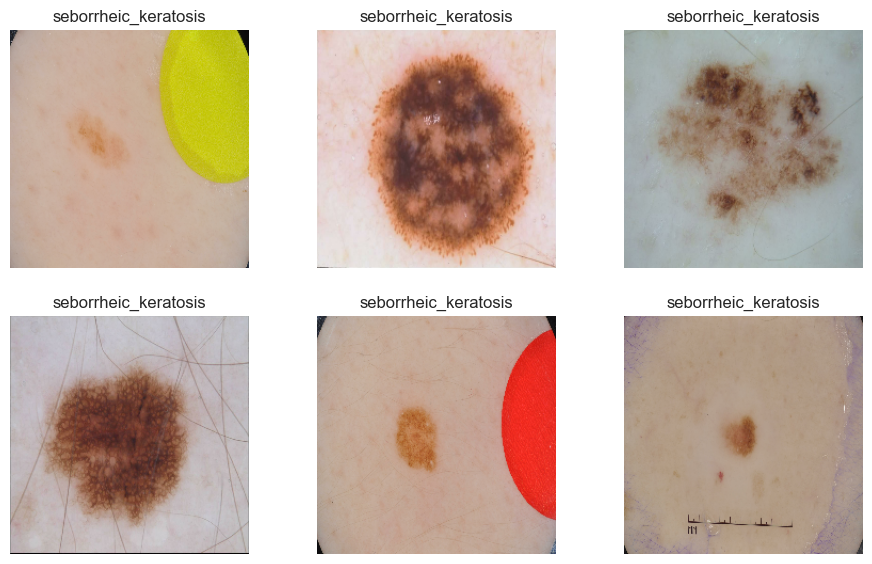

In [6]:
class_names = train_data.class_names
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
    for i in range(6):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

In [8]:
#Normalization
def normalize(data):
    norm = tf.keras.layers.Rescaling(1./255) 
    norm_data = data.map(lambda x, y: (norm(x), y))
    return norm_data

norm_train_data = normalize(train_data)
image_batch, labels_batch = next(iter(norm_train_data))
image = image_batch[3]
print(np.min(image), np.max(image))

#val data
norm_val_data = normalize(val_data)
#test data 
norm_test_data = normalize(test_data)

0.1866685 0.784007


### Imbalance ratio

In [ ]:
#get corresponding images and labels
images = []
labels = []
for image, label in norm_train_data:
    images.append(image.numpy())
    labels.append(label.numpy())

labels_flat = [label[0] for sublist in labels for label in sublist]
counts = Counter(labels_flat)
pos = counts[1] #melanoma
neg = counts[0] #keratosis
total = pos + neg
print('Total: {}\n Positive/Melanoma: {} ({:.2f}% of total)\n'.format(total, pos, 100 * pos / total))

In [10]:
AUTOTUNE = tf.data.AUTOTUNE
#Cache the data to avoid re-loading data from disk in each epoch, improving training speed.
#Prefetch data to ensure the model trains without waiting for data loading, 
#enhancing efficiency.
norm_train_data = norm_train_data.cache().prefetch(buffer_size=AUTOTUNE)
norm_val_data = norm_val_data.cache().prefetch(buffer_size=AUTOTUNE)

### Data Augmentation

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    #layers.RandomConstrast
    #layers.RandomCrop
    #layers.RandomZoom
])

## Train Model

In [12]:
METRICS = [
    tf.keras.metrics.BinaryCrossentropy(name = 'Cross Entropy'),
    tf.keras.metrics.MeanSquaredError(name = 'MSE'),
    tf.keras.metrics.TruePositives(name = 'TP'),
    tf.keras.metrics.FalsePositives(name = 'FP'),
    tf.keras.metrics.TrueNegatives(name = 'TN'),
    tf.keras.metrics.FalseNegatives(name = 'FN'),
    tf.keras.metrics.BinaryAccuracy(name = 'Accuracy'),
    tf.keras.metrics.Precision(name = 'precision'),
    tf.keras.metrics.Recall(name = 'recall'),
    tf.keras.metrics.AUC(name = 'auc'),
    tf.keras.metrics.AUC(name = 'prc', curve = 'PR'), #precision recall curve
]
def create_model(metrics=METRICS, output_bias=None):
    initializer = tf.keras.initializers.GlorotNormal()
    if output_bias is not None:
        output_bias = tf.keras.initializers.Constant(output_bias)
    
    model = tf.keras.Sequential([
        
        tf.keras.layers.Conv2D(32, kernel_size = (3,3), activation = 'relu', kernel_initializer=initializer),
        #tf.keras.layers.MaxPooling2D(),
        
        tf.keras.layers.Conv2D(64, kernel_size = (3, 3), activation = 'relu', kernel_initializer=initializer),
        tf.keras.layers.MaxPooling2D(pool_size = 2, padding = 'valid'),
        
        tf.keras.layers.Conv2D(128, kernel_size = (3, 3), activation = 'relu', kernel_initializer = initializer),
        tf.keras.layers.MaxPooling2D(pool_size = 2),
    
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation = 'relu', kernel_initializer = initializer),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation = 'relu', kernel_initializer = initializer),
        tf.keras.layers.Dense(1, activation = 'sigmoid', bias_initializer = output_bias)
    ])
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=METRICS
    )
    return model

In [14]:
input_shape = (None, 224, 224, 3) #None for batch size
callback = tf.keras.callbacks.EarlyStopping(
    monitor ='val_loss', #validation precision recall curve 
    patience = 5,
    restore_best_weights = True
)

In [15]:
model = create_model() 
history = model.fit(
    norm_train_data, 
    epochs = 20, 
    batch_size = 16,
    callbacks = [callback],
    validation_data = norm_val_data, 
    verbose = 1
) 

Epoch 1/20
63/63 [==============================] - 231s 4s/step - loss: 0.5157 - Cross Entropy: 0.5157 - MSE: 0.1610 - TP: 7.0000 - FP: 31.0000 - TN: 1595.0000 - FN: 367.0000 - Accuracy: 0.8010 - precision: 0.1842 - recall: 0.0187 - auc: 0.5119 - prc: 0.1858 - val_loss: 0.4916 - val_Cross Entropy: 0.4916 - val_MSE: 0.1572 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 120.0000 - val_FN: 30.0000 - val_Accuracy: 0.8000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.6967 - val_prc: 0.3739
Epoch 2/20
63/63 [==============================] - 214s 3s/step - loss: 0.4770 - Cross Entropy: 0.4770 - MSE: 0.1508 - TP: 0.0000e+00 - FP: 0.0000e+00 - TN: 1626.0000 - FN: 374.0000 - Accuracy: 0.8130 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.5776 - prc: 0.2190 - val_loss: 0.4793 - val_Cross Entropy: 0.4793 - val_MSE: 0.1540 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 120.0000 - val_FN: 30.0000 - val_Accuracy: 0.8000 - val_precision: 0.0000e+00 - val_recall: 

In [16]:
test_prediction = model.predict(norm_test_data) 

19/19 [==============================] - 17s 643ms/step


loss :  1.4058293104171753
Cross Entropy :  1.4058293104171753
MSE :  0.19135263562202454
TP :  16.0
FP :  29.0
TN :  454.0
FN :  101.0
Accuracy :  0.7833333611488342
precision :  0.35555556416511536
recall :  0.1367521435022354
auc :  0.5903010368347168
prc :  0.27912741899490356

Keratosis (True Negatives):  448
 (False Positives): 35
(False Negatives):  107
 Melanoma (True Positives): 10
Total: 117


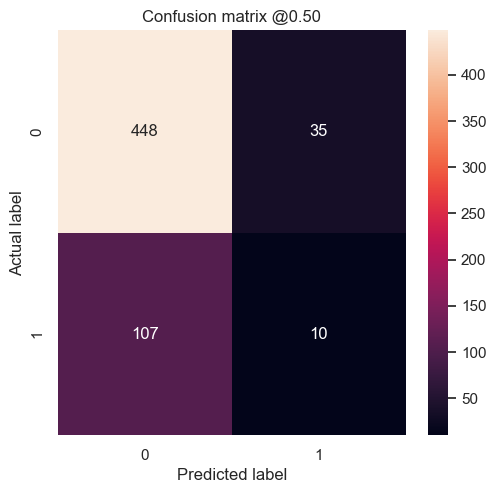

In [19]:
results = model.evaluate(norm_test_data, verbose=0)
for name, value in zip(model.metrics_names, results):
    print(name, ': ', value) 

print() 
plot_cm(labels_flat, test_prediction) 

In [16]:
model = create_model() 
results = model.evaluate(norm_train_data, verbose = 0) 
print("loss: {:0.4f}".format(results[0])) 

loss: 0.5580


### Set initial bias
The correct bias to set can be derived from: <br>
p0 = pos/(pos + neg) = 1/(1+e<sup>-b0</sup>) <br>
b0 = -log<sub>e</sub><sup>(1/p0-1)</sup> <br>
b0 = log<sub>e</sub><sup>(pos/neg)</sup> <br>

In [17]:
initial_bias = np.log([pos/neg]) 
print(f"initial bias: {initial_bias}") 
#set as the initial bias and evaluate 
model = create_model(output_bias = initial_bias) 
#model.predict(norm_train_data) 

initial bias: [-1.46962249]


In [18]:
results = model.evaluate(norm_train_data, verbose = 0)
print("loss: {:0.4f}".format(results[0]))

loss: 0.4819


In [19]:
#Keeping initial weights in a checkpoint file, and load them into each model before training
initial_weights = os.path.join(tempfile.mkdtemp(), 'initial_weights')
model.save_weights(initial_weights) 

In [20]:
#zero bias
#model = create_model(output_bias = initial_bias)
model.load_weights(initial_weights)
model.layers[-1].bias.assign([0.0])
zero_bias_history = model.fit(
    norm_train_data, 
    epochs = 20, 
    batch_size = 16,
    callbacks = [callback],
    validation_data = norm_val_data, 
    verbose = 2
)

Epoch 1/20
63/63 - 106s - loss: 0.4926 - Cross Entropy: 0.4926 - MSE: 0.1565 - TP: 5.0000 - FP: 24.0000 - TN: 1602.0000 - FN: 369.0000 - Accuracy: 0.8035 - Precision: 0.1724 - Recall: 0.0134 - AUC: 0.5273 - prc: 0.1913 - val_loss: 0.4859 - val_Cross Entropy: 0.4859 - val_MSE: 0.1559 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 120.0000 - val_FN: 30.0000 - val_Accuracy: 0.8000 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_AUC: 0.6357 - val_prc: 0.3332 - 106s/epoch - 2s/step
Epoch 2/20
63/63 - 96s - loss: 0.4740 - Cross Entropy: 0.4740 - MSE: 0.1501 - TP: 0.0000e+00 - FP: 0.0000e+00 - TN: 1626.0000 - FN: 374.0000 - Accuracy: 0.8130 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - AUC: 0.5770 - prc: 0.2304 - val_loss: 0.4814 - val_Cross Entropy: 0.4814 - val_MSE: 0.1549 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 120.0000 - val_FN: 30.0000 - val_Accuracy: 0.8000 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_AUC: 0.6639 - val_prc: 0.3472 - 96s/epoch -

In [21]:
model = create_model(output_bias = initial_bias)
model.load_weights(initial_weights)
history = model.fit(
    norm_train_data, 
    epochs = 20, 
    batch_size = 16,
    callbacks = [callback],
    validation_data = norm_val_data, 
    verbose = 2
)

Epoch 1/20
63/63 - 105s - loss: 0.4819 - Cross Entropy: 0.4835 - MSE: 0.1529 - TP: 0.0000e+00 - FP: 3.0000 - TN: 1743.0000 - FN: 404.0000 - Accuracy: 0.8107 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - AUC: 0.5408 - prc: 0.2048 - val_loss: 0.4927 - val_Cross Entropy: 0.4927 - val_MSE: 0.1580 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 120.0000 - val_FN: 30.0000 - val_Accuracy: 0.8000 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_AUC: 0.5999 - val_prc: 0.2515 - 105s/epoch - 2s/step
Epoch 2/20
63/63 - 100s - loss: 0.4798 - Cross Entropy: 0.4798 - MSE: 0.1517 - TP: 0.0000e+00 - FP: 0.0000e+00 - TN: 1626.0000 - FN: 374.0000 - Accuracy: 0.8130 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - AUC: 0.5308 - prc: 0.2007 - val_loss: 0.4959 - val_Cross Entropy: 0.4959 - val_MSE: 0.1591 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 120.0000 - val_FN: 30.0000 - val_Accuracy: 0.8000 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_AUC: 0.5497 - val_prc: 0.2000 -

In [22]:
def plot_loss(history, label, n):
    plt.semilogy(history.epoch, history.history['loss'],
                 color = colors[n], label = 'Train' + label)
    plt.semilogy(history.epoch, history.history['val_loss'],
                 color = colors[n], label = 'Val' + label,
                 linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

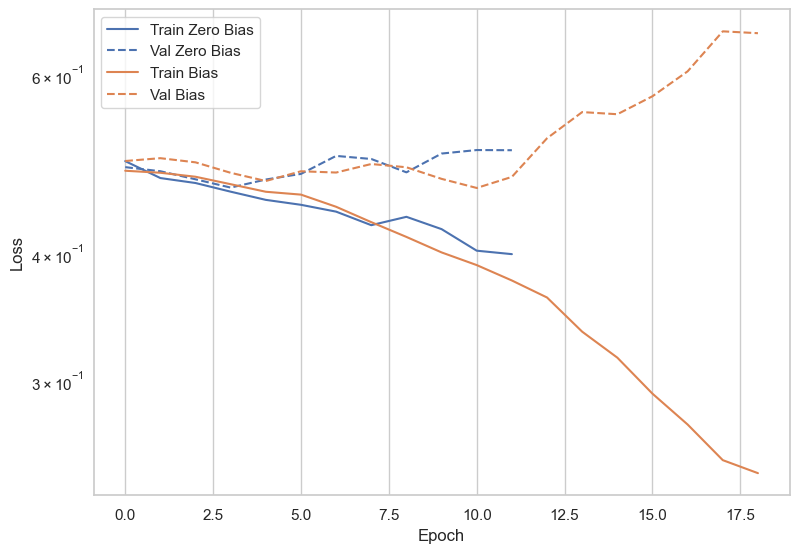

In [23]:
plot_loss(zero_bias_history, " Zero Bias", 0)
plot_loss(history, " Bias", 1)

In [24]:
#Plot Metrics
def plot_metrics(history):
    metrics = ['loss', 'prc', 'Precision', 'Recall']
    for n, metric in enumerate(metrics):
        name = metric.replace("_", " ").capitalize()
        plt.subplot(2,2, n+1)
        plt.plot(history.epoch, history.history[metric], color=colors[0], label='Train')
        plt.plot(history.epoch, history.history['val_'+metric],
        color=colors[0], linestyle='--', label='Val')
        plt.xlabel('Epoch')
        plt.ylabel(name)
        if metric == 'loss':
            plt.ylim([0, plt.ylim()[1]])
        elif metric == 'auc':
            plt.ylim(0.8, 1)
        else:
            plt.ylim([0, 1])
    plt.legend()

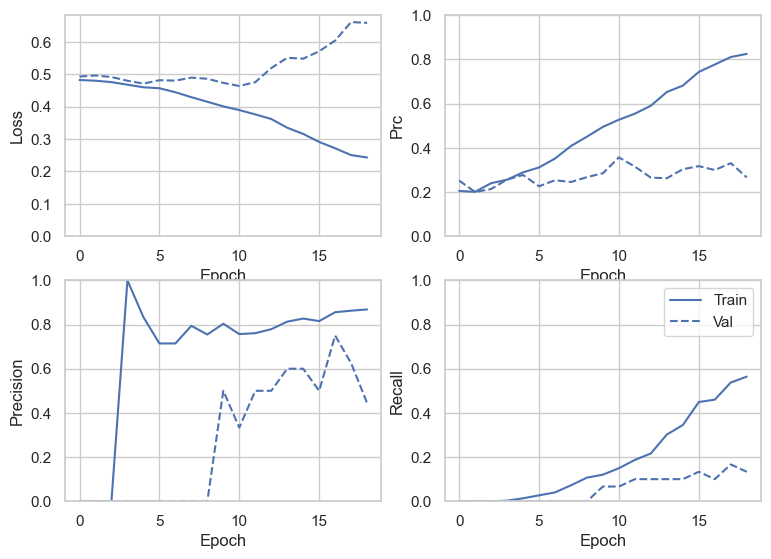

In [25]:
plot_metrics(history)

### Confusion Matrix

In [26]:
train_prediction = model.predict(norm_train_data, batch_size = batch_size)
test_prediction = model.predict(norm_test_data, batch_size = batch_size)

19/19 [==============================] - 10s 339ms/step


In [17]:
def plot_cm(labels, predictions, threshold= 0.5):
    cm = confusion_matrix(labels, predictions > threshold)
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title('Confusion matrix @{:.2f}'.format(threshold))
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')

    print('Keratosis (True Negatives): ', cm[0][0])
    print(' (False Positives):', cm[0][1])
    print('(False Negatives): ', cm[1][0])
    print(' Melanoma (True Positives):', cm[1][1])
    print('Total:', np.sum(cm[1]))
    

In [18]:
#get corresponding images and labels
images = []
labels = []
for image, label in norm_test_data:
    images.append(image.numpy())
    labels.append(label.numpy())

labels_flat = [label[0] for sublist in labels for label in sublist]

loss :  0.5002156496047974
Cross Entropy :  0.5002156496047974
MSE :  0.1620897352695465
TP :  10.0
FP :  29.0
TN :  454.0
FN :  107.0
Accuracy :  0.7733333110809326
Precision :  0.25641027092933655
Recall :  0.08547008782625198
AUC :  0.6525986194610596
prc :  0.282934308052063

Keratosis (True Negatives):  453
 (False Positives): 30
(False Negatives):  108
 Melanoma (True Positives): 9
Total: 117


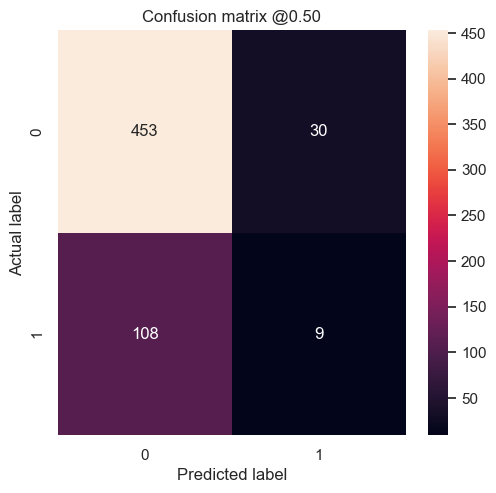

In [32]:
results = model.evaluate(norm_test_data, batch_size = batch_size, verbose=0)
for name, value in zip(model.metrics_names, results):
    print(name, ': ', value)

print()
plot_cm(labels_flat, test_prediction)

### Class Weights

In [35]:
weight_0 = (1/neg) * (total / 2.0)
weight_1 = (1/pos) * (total / 2.0)
class_weight = {0: weight_0, 1: weight_1}
print('Weight for class 0: {:.2f}'.format(weight_0))
print('Weight for class 1: {:.2f}'.format(weight_1))

Weight for class 0: 0.62
Weight for class 1: 2.67


In [36]:
#Train with class weights
weighted_model = create_model()
weighted_model.load_weights(initial_weights)

weighted_history = weighted_model.fit(
    norm_train_data,
    batch_size = batch_size,
    epochs = 20,
    callbacks=[callback],
    validation_data=(norm_val_data),
    class_weight = class_weight,
    verbose = 1,
)

Epoch 1/20
63/63 [==============================] - 47s 732ms/step - loss: 0.7224 - Cross Entropy: 0.6434 - MSE: 0.2271 - TP: 133.0000 - FP: 632.0000 - TN: 1477.0000 - FN: 358.0000 - Accuracy: 0.6192 - Precision: 0.1739 - Recall: 0.2709 - AUC: 0.4912 - prc: 0.1833 - val_loss: 0.6872 - val_Cross Entropy: 0.6872 - val_MSE: 0.2474 - val_TP: 16.0000 - val_FP: 60.0000 - val_TN: 60.0000 - val_FN: 14.0000 - val_Accuracy: 0.5067 - val_Precision: 0.2105 - val_Recall: 0.5333 - val_AUC: 0.4940 - val_prc: 0.1856
Epoch 2/20
63/63 [==============================] - 51s 806ms/step - loss: 0.7032 - Cross Entropy: 0.6799 - MSE: 0.2439 - TP: 153.0000 - FP: 675.0000 - TN: 951.0000 - FN: 221.0000 - Accuracy: 0.5520 - Precision: 0.1848 - Recall: 0.4091 - AUC: 0.5020 - prc: 0.1886 - val_loss: 0.7762 - val_Cross Entropy: 0.7762 - val_MSE: 0.2916 - val_TP: 26.0000 - val_FP: 103.0000 - val_TN: 17.0000 - val_FN: 4.0000 - val_Accuracy: 0.2867 - val_Precision: 0.2016 - val_Recall: 0.8667 - val_AUC: 0.5008 - val_p

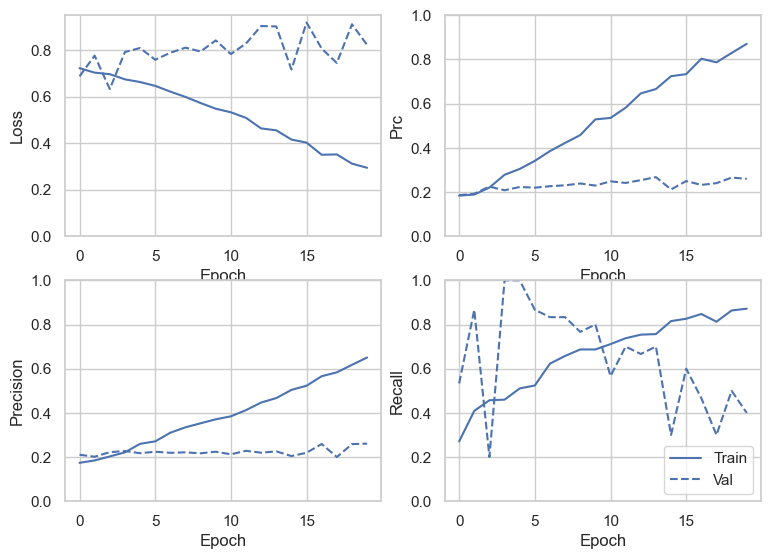

In [37]:
plot_metrics(weighted_history)

In [38]:
#Evaluation metrics
train_prediction_w = weighted_model.predict(norm_train_data, batch_size = batch_size)
test_prediction_w = weighted_model.predict(norm_test_data, batch_size = batch_size)

19/19 [==============================] - 11s 351ms/step


loss :  0.7504783272743225
Cross Entropy :  0.7504783272743225
MSE :  0.24266403913497925
TP :  48.0
FP :  130.0
TN :  353.0
FN :  69.0
Accuracy :  0.6683333516120911
Precision :  0.26966291666030884
Recall :  0.41025641560554504
AUC :  0.5911238789558411
prc :  0.2594127953052521

Keratosis (True Negatives):  335
 (False Positives): 148
(False Negatives):  87
 Melanoma (True Positives): 30
Total: 117


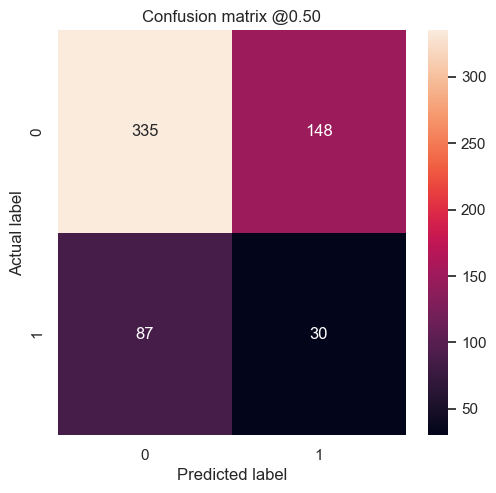

In [39]:
results_w = weighted_model.evaluate(norm_test_data, batch_size = batch_size, verbose=0)
for name, value in zip(weighted_model.metrics_names, results):
    print(name, ': ', value)

print()
plot_cm(labels_flat, test_prediction)

In [40]:
#save the model
from tensorflow.keras.models import save_model, load_model
save_model(weighted_model, 'weighted_cnn_with_dropout.h5')